# **OPSD Dataset**

In [ ]:
!gdown 1qW7tPUw3u3Dn4kuBEoV8XwLYpetBDVjr

Downloading...
From: https://drive.google.com/uc?id=1qW7tPUw3u3Dn4kuBEoV8XwLYpetBDVjr
To: /content/opsd_germany_daily.csv
100% 222k/222k [00:00<00:00, 33.1MB/s]


In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
dataset_path = '/content/opsd_germany_daily.csv'

In [94]:
opsd_daily = pd.read_csv(dataset_path, index_col="Date", parse_dates=True)

In [95]:
opsd_daily

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.18400,NaN,NaN,NaN
2006-01-02,1380.52100,NaN,NaN,NaN
2006-01-03,1442.53300,NaN,NaN,NaN
2006-01-04,1457.21700,NaN,NaN,NaN
2006-01-05,1477.13100,NaN,NaN,NaN
...,...,...,...,...
2017-12-27,1263.94091,394.507,16.530,411.037
2017-12-28,1299.86398,506.424,14.162,520.586
2017-12-29,1295.08753,584.277,29.854,614.131


In [96]:
opsd_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4383 entries, 2006-01-01 to 2017-12-31
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Consumption  4383 non-null   float64
 1   Wind         2920 non-null   float64
 2   Solar        2188 non-null   float64
 3   Wind+Solar   2187 non-null   float64
dtypes: float64(4)
memory usage: 171.2 KB


## Time-based indexing

In [80]:
pd.to_datetime('6/6/2024')

Timestamp('2024-06-06 00:00:00')

In [97]:
opsd_daily.loc['2015-02-15':'2016-07-07']

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2015-02-15,1261.167,202.852,60.942,263.794
2015-02-16,1536.780,204.535,60.863,265.398
2015-02-17,1600.019,64.951,40.310,105.261
2015-02-18,1611.379,134.261,40.082,174.343
2015-02-19,1607.741,243.061,62.938,305.999
...,...,...,...,...
2016-07-03,1064.118,184.803,161.292,346.095
2016-07-04,1375.612,55.848,183.524,239.372
2016-07-05,1416.841,337.075,166.213,503.288


In [98]:
opsd_daily.loc['2015-02']

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2015-02-01,1273.828,121.819,24.680,146.499
2015-02-02,1608.680,197.405,20.268,217.673
2015-02-03,1639.260,97.155,27.530,124.685
2015-02-04,1651.314,40.218,31.950,72.168
2015-02-05,1647.357,127.519,29.040,156.559
2015-02-06,1620.507,168.548,46.344,214.892
2015-02-07,1408.553,284.226,55.924,340.150
2015-02-08,1296.855,405.421,52.429,457.850
2015-02-09,1618.607,382.505,15.049,397.554


In [99]:
opsd_daily.index.day_name()

Index(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday',
       'Saturday', 'Sunday', 'Monday', 'Tuesday',
       ...
       'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday',
       'Thursday', 'Friday', 'Saturday', 'Sunday'],
      dtype='object', name='Date', length=4383)

In [100]:
opsd_daily.index.month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
      dtype='int32', name='Date', length=4383)

## Visualization

<Axes: xlabel='Date'>

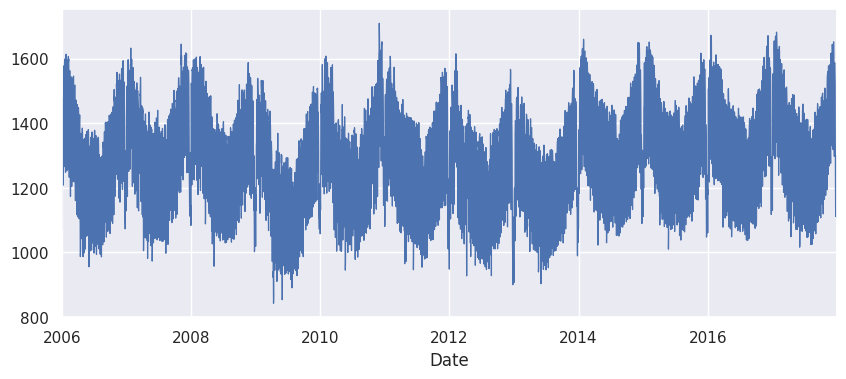

In [101]:
sns.set(rc={'figure.figsize':(10,4)})
opsd_daily['Consumption'].plot(linewidth=0.9)

<Axes: xlabel='Date'>

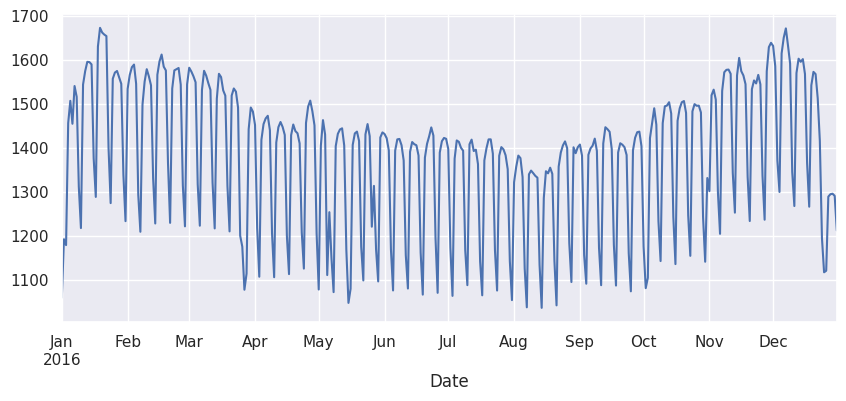

In [102]:
opsd_daily.loc['2016', 'Consumption'].plot()

## Seasonality

In [109]:
opsd_daily['Month'] = opsd_daily.index.month

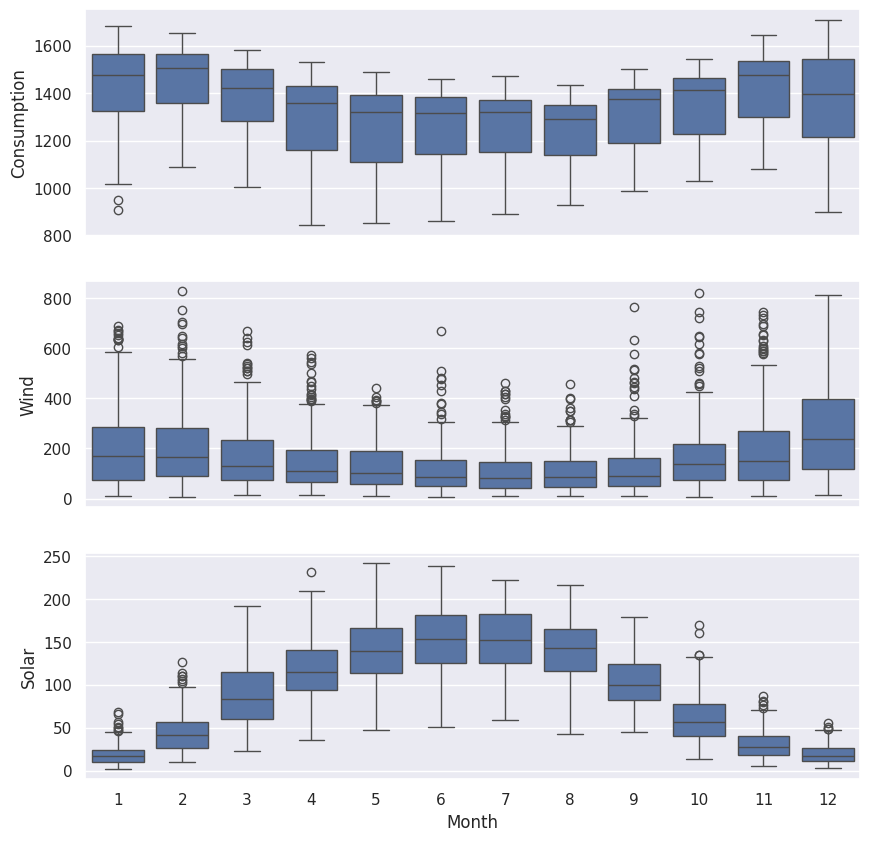

In [110]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for name, ax in zip(["Consumption", "Wind", "Solar"], axes):
    sns.boxplot(data=opsd_daily, x="Month", y=name, ax=ax)

## Frequencies

In [117]:
pd.date_range('2024-08-25', '2024-08-30', freq='D')

DatetimeIndex(['2024-08-25', '2024-08-26', '2024-08-27', '2024-08-28',
               '2024-08-29', '2024-08-30'],
              dtype='datetime64[ns]', freq='D')

In [119]:
pd.date_range('2024-08-25', periods=8, freq='YE')

DatetimeIndex(['2024-12-31', '2025-12-31', '2026-12-31', '2027-12-31',
               '2028-12-31', '2029-12-31', '2030-12-31', '2031-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')

## Resampling

In [121]:
times_sample = pd.to_datetime(['2014-02-02', '2014-02-05', '2014-02-08'])

In [123]:
consum_sample = opsd_daily.loc[times_sample, 'Consumption'].copy()
consum_sample

,Consumption
2014-02-02,1265.416
2014-02-05,1623.241
2014-02-08,1365.813


In [124]:
consum_freq = consum_sample.asfreq('D')
consum_freq

,Consumption
2014-02-02,1265.416
2014-02-03,NaN
2014-02-04,NaN
2014-02-05,1623.241
2014-02-06,NaN
2014-02-07,NaN
2014-02-08,1365.813


In [126]:
consum_freq = consum_sample.asfreq('D', method='ffill')
consum_freq

,Consumption
2014-02-02,1265.416
2014-02-03,1265.416
2014-02-04,1265.416
2014-02-05,1623.241
2014-02-06,1623.241
2014-02-07,1623.241
2014-02-08,1365.813


In [127]:
consum_freq = consum_sample.asfreq('D', method='bfill')
consum_freq

,Consumption
2014-02-02,1265.416
2014-02-03,1623.241
2014-02-04,1623.241
2014-02-05,1623.241
2014-02-06,1365.813
2014-02-07,1365.813
2014-02-08,1365.813


In [129]:
data_columns = ['Consumption', 'Wind', 'Solar', 'Wind+Solar']
opsd_daily_freq = opsd_daily[data_columns].resample('ME').mean()
opsd_daily_freq

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-31,1461.442065,NaN,NaN,NaN
2006-02-28,1467.106893,NaN,NaN,NaN
2006-03-31,1418.649161,NaN,NaN,NaN
2006-04-30,1275.058900,NaN,NaN,NaN
2006-05-31,1253.488484,NaN,NaN,NaN
...,...,...,...,...
2017-08-31,1291.283022,177.412839,148.477677,325.890516
2017-09-30,1335.952031,209.591000,102.643033,312.234033
2017-10-31,1366.297385,402.583774,68.727645,471.311419


## Rolling Windows

In [130]:
opsd_daily[data_columns].rolling(7, center=True).mean()

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,NaN,NaN,NaN,NaN
2006-01-02,NaN,NaN,NaN,NaN
2006-01-03,NaN,NaN,NaN,NaN
2006-01-04,1361.471429,NaN,NaN,NaN
2006-01-05,1381.300143,NaN,NaN,NaN
...,...,...,...,...
2017-12-27,1208.214129,617.734286,17.807143,635.541429
2017-12-28,1203.265211,604.699143,19.240143,623.939286
2017-12-29,NaN,NaN,NaN,NaN


## Trends

In [131]:
opsd_7d = opsd_daily[data_columns].rolling(7, center=True).mean()

In [132]:
opsd_365d = opsd_daily[data_columns].rolling(
    window=365,
    center=True,
    min_periods=180
).mean()

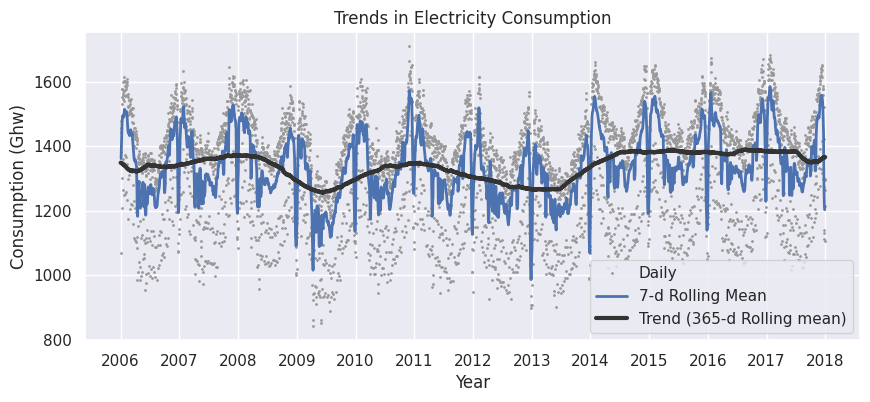

In [133]:
import matplotlib.dates as mdates

opsd_365d = opsd_daily[data_columns].rolling(
    window=365,
    center=True,
    min_periods=180
).mean()

# Plot daily, 7-day rolling mean, and 365-day rolling mean time series
fig, ax = plt.subplots()
ax.plot(opsd_daily['Consumption'], marker='.', markersize=2, color='0.6', linestyle='None', label='Daily')
ax.plot(opsd_7d['Consumption'], linewidth=2, label='7-d Rolling Mean')
ax.plot(opsd_365d['Consumption'], color='0.2', linewidth=3, label='Trend (365-d Rolling mean)')
# Set x-ticks to yearly interval and add legend and labels
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Consumption (Ghw)')
ax.set_title('Trends in Electricity Consumption')
plt.show()